In [1]:
# --- Instalação de Dependências (Execute isso no terminal ou na primeira célula do notebook) ---
# !pip install spacy pandas matplotlib wordcloud
# !python -m spacy download pt_core_news_sm

import pandas as pd
import re
import spacy
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud


In [2]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 56.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Dataset 'tabela_final.csv' carregado com sucesso!

Número inicial de tweets: 300

--- Iniciando Pipeline (Limpeza -> Lematização -> Stopwords) ---
Isso pode levar alguns instantes dependendo do tamanho do dataset...

Primeiras 5 linhas após o processamento:
                                               Tweet  \
0  "Ain vcs tão comemorando que salvaram um caval...   
1  "Se a Manuela for eleita, vocês vão comer carn...   
2  "o meu sensor de piriguete explodiu" fala séri...   
3  *LULA TEM RAZÃO! E ele não está sozinho* A his...   
4  *Sana entra no quarto e puxa meu cabelo me jog...   

                                  Tweets_Processados  
0  [ain, vcs, comemorar, salvar, cavalo, vadir, e...  
1  [manuela, eleita, comer, carne, cachorro, maio...  
2  [sensor, piriguete, explodir, falar, sério, im...  
3  [Lula, razão, sozinho, histórico, declaração, ...  
4  [sano, entrar, puxa, cabelo, jogar, chão, sana...  

Dataset pré-processado salvo como 'tabela_final_pre_processada_spacy.csv'


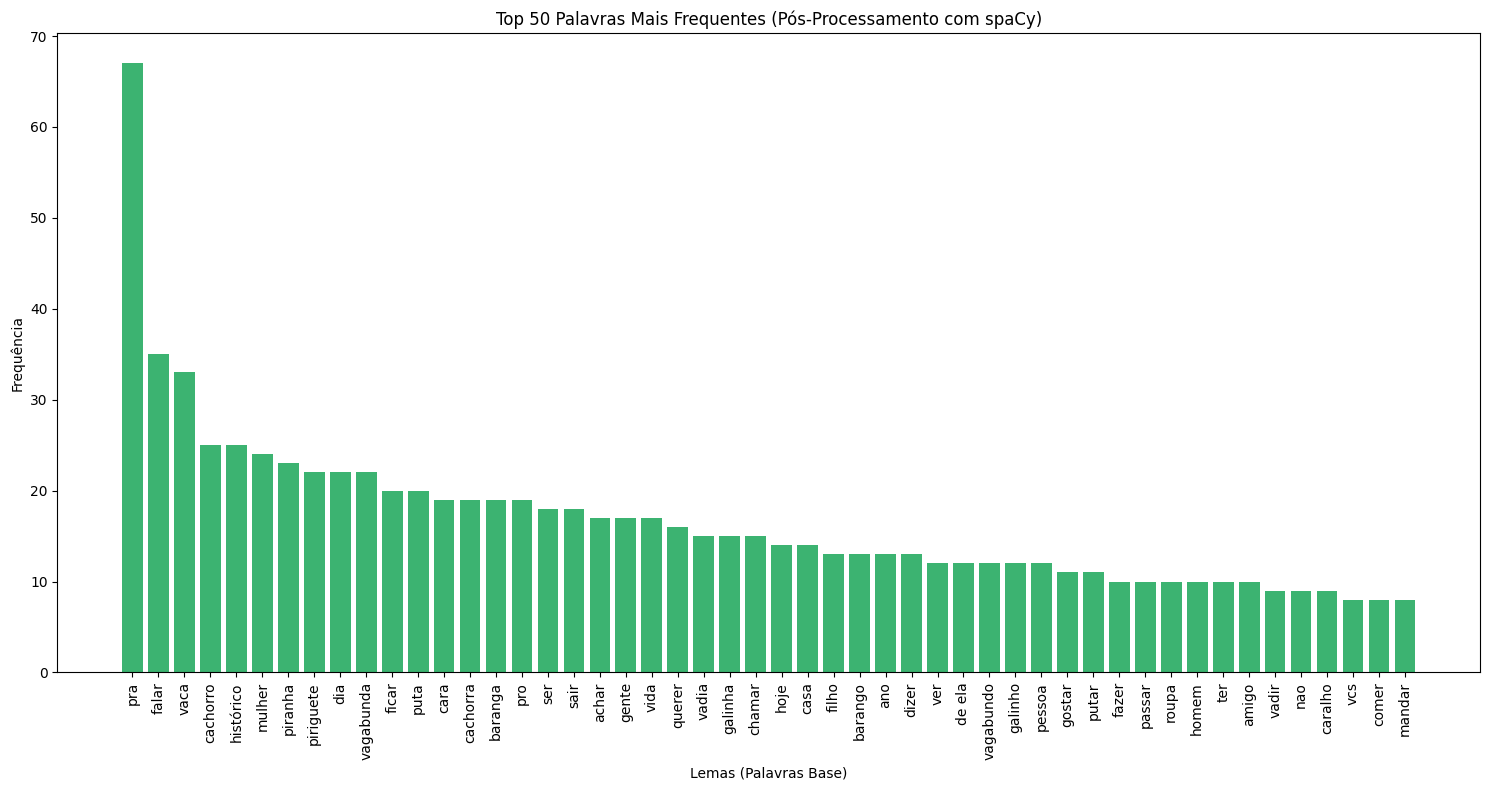


--- Gerando Nuvem de Palavras ---


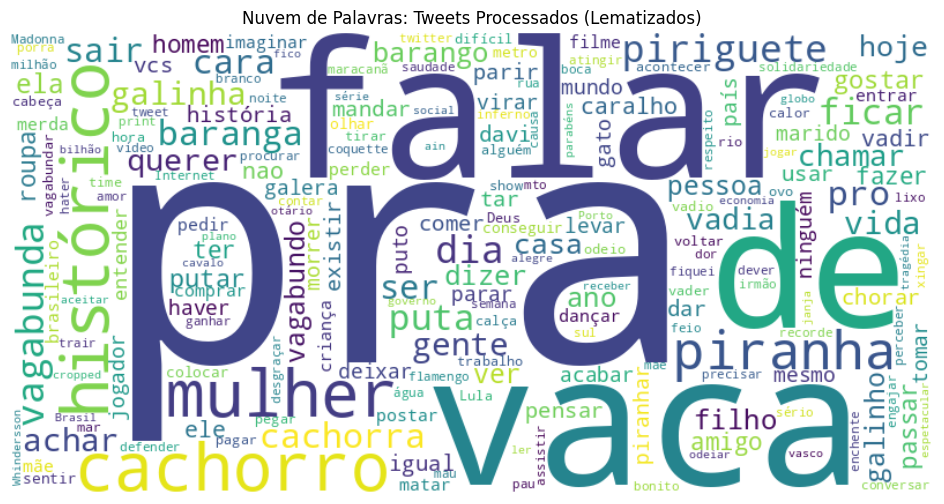


Processo Finalizado!


In [3]:
# Carregando o modelo de língua portuguesa do spaCy
# Isso substitui o NLTK para Tokenização e Lematização com muito mais precisão
try:
    nlp = spacy.load("pt_core_news_sm")
except OSError:
    print("O modelo 'pt_core_news_sm' não foi encontrado.")
    print("Por favor, execute no terminal: python -m spacy download pt_core_news_sm")
    exit()

# --- 0. Carregar o Dataset ---
try:
    # Substitua pelo caminho correto do seu arquivo se necessário
    df = pd.read_csv('tabela_final.csv')
    print("Dataset 'tabela_final.csv' carregado com sucesso!")
except FileNotFoundError:
    print("Erro: O arquivo 'tabela_final.csv' não foi encontrado.")
    exit()

print(f"\nNúmero inicial de tweets: {len(df)}")

# --- 1. Pré-processamento Unificado (Limpeza -> Lematização -> Stopwords) ---

# Recuperamos as stopwords padrão do spaCy para português
all_stopwords = nlp.Defaults.stop_words

# Adicione aqui palavras extras que você quer remover (ex: gírias comuns do twitter que não agregam valor)
# all_stopwords |= {"pra", "vc", "né", "tá", "q"}

def preprocess_pipeline(text):
    if not isinstance(text, str):
        return []

    # 1.1 Limpeza via Regex (Mantida do seu código original para remover URLs e Handles)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text) # Remove menções e hashtags
    text = re.sub(r'[^\w\s]', '', text) # Remove pontuação
    text = re.sub(r'\s+', ' ', text).strip() # Remove espaços duplos

    # 1.2 Processamento NLP com spaCy
    # O 'nlp(text)' faz Tokenização, Tagging (POS) e Lematização internamente
    doc = nlp(text.lower())

    cleaned_tokens = []

    for token in doc:
        # AQUI ACONTECE A MÁGICA:
        # token.lemma_ -> Pega a forma lematizada (ex: "correndo" vira "correr")
        # token.is_stop -> Verifica se é stopword
        # token.is_alpha -> Verifica se é apenas letra (remove números soltos ou sujeira)

        lemma = token.lemma_

        # Lógica: Se o LEMA não for stopword e for alfabético, adicionamos à lista
        if not token.is_stop and token.is_alpha and len(lemma) > 2:
            cleaned_tokens.append(lemma)

    return cleaned_tokens

print("\n--- Iniciando Pipeline (Limpeza -> Lematização -> Stopwords) ---")
print("Isso pode levar alguns instantes dependendo do tamanho do dataset...")

# Aplicando a função
df['Tweets_Processados'] = df['Tweet'].apply(preprocess_pipeline)

print("\nPrimeiras 5 linhas após o processamento:")
print(df[['Tweet', 'Tweets_Processados']].head())

# --- Salvar o Dataset Final Processado ---
output_filename = 'tabela_final_pre_processada_spacy.csv'
# Convertemos a lista de volta para string para salvar no CSV sem quebrar formato
df.to_csv(output_filename, index=False)
print(f"\nDataset pré-processado salvo como '{output_filename}'")


# --- 2. Visualização: Gráfico de Barras (Frequência de Lemas) ---

print("\n--- Gerando Gráfico de Frequência ---")

# "Achatando" a lista de listas para contar todos os tokens
all_lemmatized_tokens = [token for sublist in df['Tweets_Processados'] for token in sublist]

# Contagem
token_counts = Counter(all_lemmatized_tokens)
top_n = 50
most_common_tokens = token_counts.most_common(top_n)

tokens = [item[0] for item in most_common_tokens]
counts = [item[1] for item in most_common_tokens]

plt.figure(figsize=(15, 8))
plt.bar(tokens, counts, color='mediumseagreen') # Mudei a cor para diferenciar
plt.xlabel('Lemas (Palavras Base)')
plt.ylabel('Frequência')
plt.title(f'Top {top_n} Palavras Mais Frequentes (Pós-Processamento com spaCy)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# --- 3. Visualização: Nuvem de Palavras (WordCloud) ---

print("\n--- Gerando Nuvem de Palavras ---")

# Juntando tudo em uma string única para a WordCloud
text_for_cloud = ' '.join(all_lemmatized_tokens)

if len(text_for_cloud) > 0:
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          collocations=False, # Importante: False para não repetir frases, já que bagunçamos a ordem
                          max_words=200
                         ).generate(text_for_cloud)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nuvem de Palavras: Tweets Processados (Lematizados)')
    plt.show()
else:
    print("Atenção: Não há palavras suficientes para gerar a nuvem após a limpeza.")

print("\nProcesso Finalizado!")

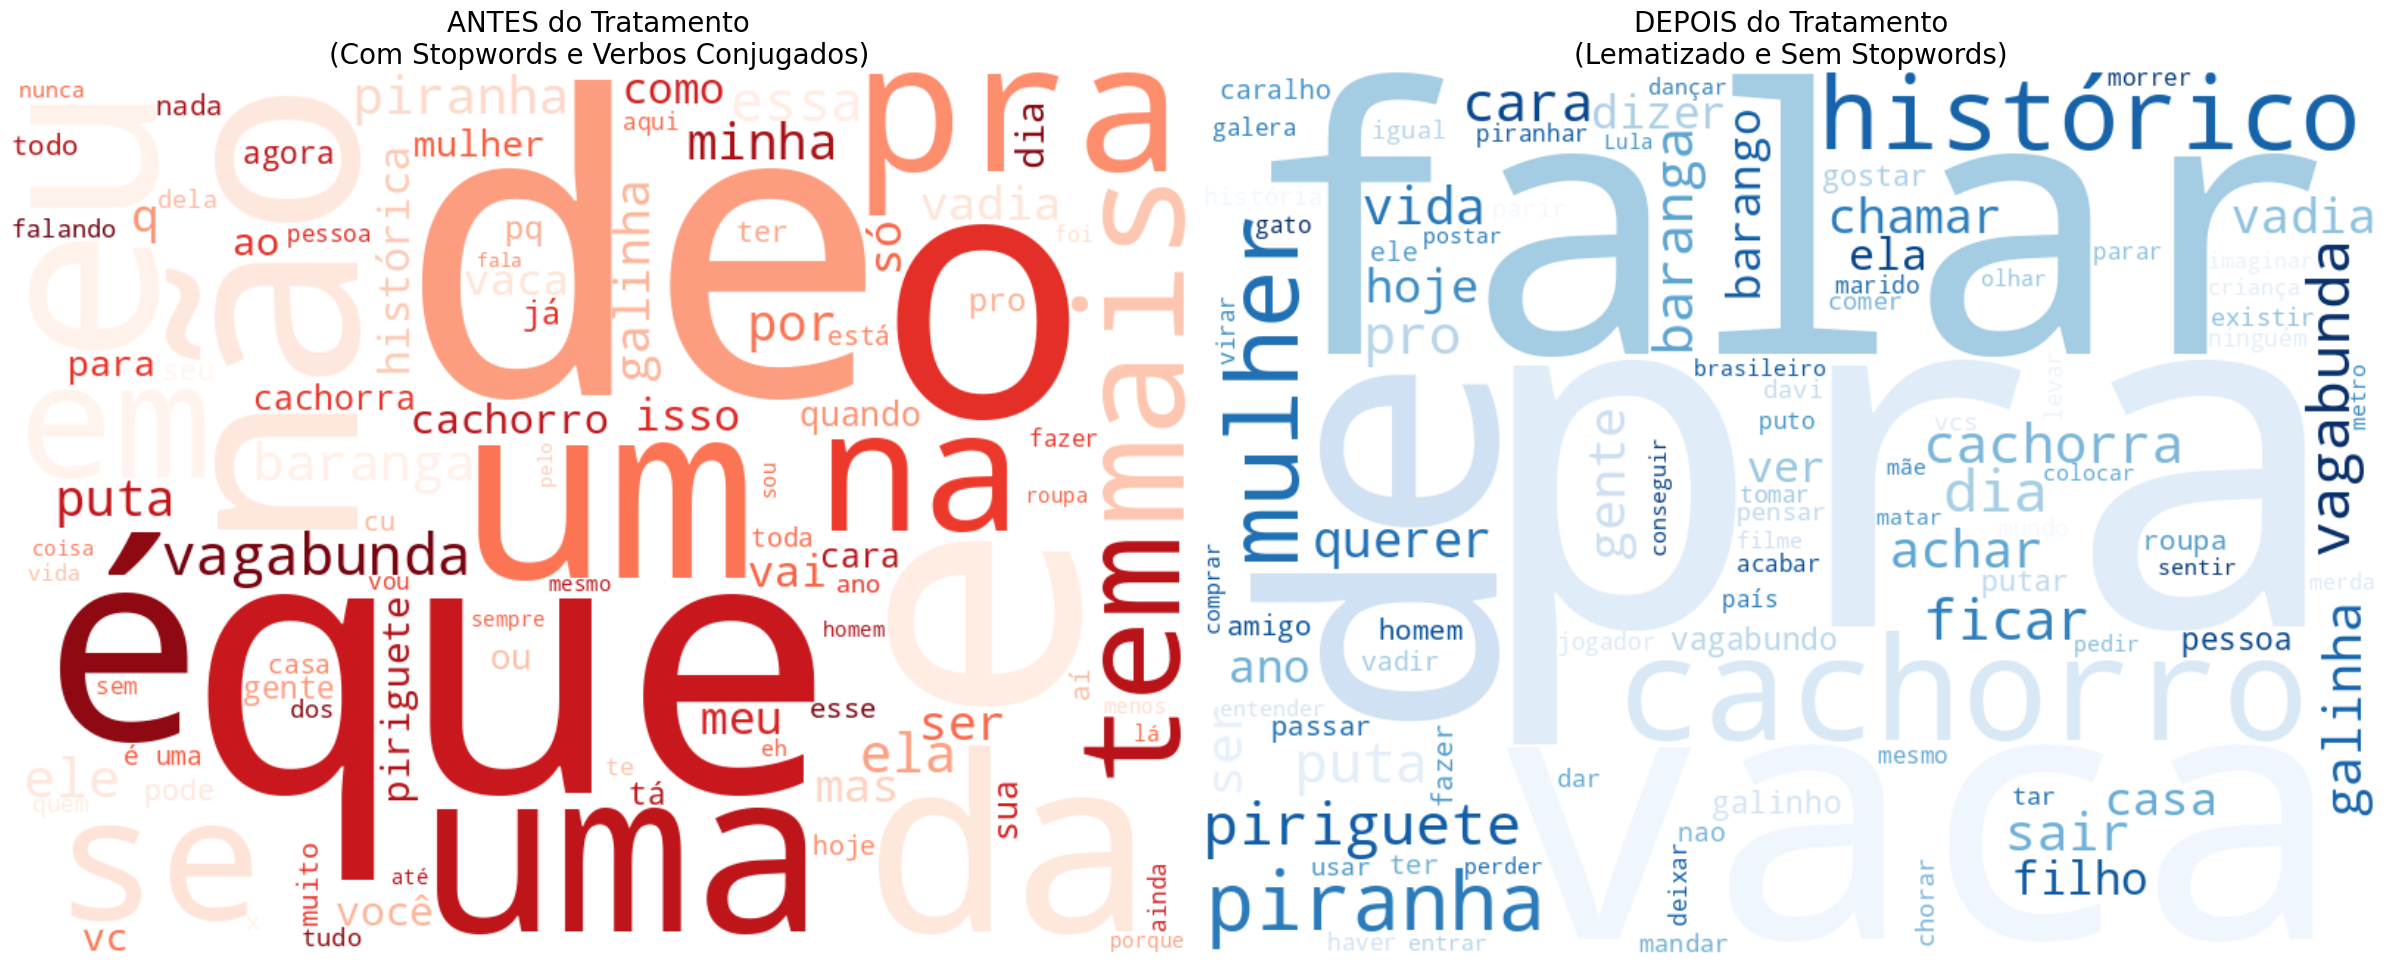

In [5]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

# --- 1. Preparar os Textos ---

# TEXTO ANTES (BRUTO)
# Fazemos apenas uma limpeza leve de URLs e @s para a nuvem não ficar ilegível,
# mas mantemos as stopwords e conjugações para mostrar a "sujeira" original.
def clean_visual_only(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    return text

# Juntamos todos os tweets originais em uma única string gigante
text_before = ' '.join(df['Tweet'].apply(clean_visual_only))

# TEXTO DEPOIS (PROCESSADO)
# Juntamos as listas de tokens lematizados em uma única string gigante
# 'Tweets_Processados' é uma lista de palavras, então fazemos um join duplo
text_after = ' '.join([' '.join(tokens) for tokens in df['Tweets_Processados']])

# --- 2. Gerar as Nuvens ---

# Nuvem 1: Antes
# Nota: Não passamos lista de stopwords aqui propositalmente para vê-las aparecendo
wc_before = WordCloud(width=800, height=600,
                      background_color='white',
                      max_words=100,
                      colormap='Reds' # Cor avermelhada para dar ideia de "bruto/alerta"
                     ).generate(text_before)

# Nuvem 2: Depois
wc_after = WordCloud(width=800, height=600,
                     background_color='white',
                     collocations=False, # False para não juntar palavras, pois a ordem original foi perdida
                     max_words=100,
                     colormap='Blues' # Cor esverdeada para dar ideia de "limpo/processado"
                    ).generate(text_after)

# --- 3. Plotar Lado a Lado ---

fig, axes = plt.subplots(1, 2, figsize=(24, 12)) # Tamanho grande para ver bem

# Plot 1
axes[0].imshow(wc_before, interpolation='bilinear')
axes[0].set_title("ANTES do Tratamento\n(Com Stopwords e Verbos Conjugados)", fontsize=20)
axes[0].axis('off')

# Plot 2
axes[1].imshow(wc_after, interpolation='bilinear')
axes[1].set_title("DEPOIS do Tratamento\n(Lematizado e Sem Stopwords)", fontsize=20)
axes[1].axis('off')

plt.tight_layout()
plt.show()